Roll Number: CH.SC.U4CSE24123
Name: M A Kaushik
K-NEAREST NEIGHBOURS 2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
data = {
    'Brightness': [40, 50, 60, 10, 70, 60, 25],
    'Saturation': [20, 50, 90, 25, 70, 10, 80],
    'Class':      ['Red', 'Blue', 'Blue', 'Red', 'Blue', 'Red', 'Blue']
}
df = pd.DataFrame(data)
new_entry = np.array([45, 40])
df

,Brightness,Saturation,Class
0,40,20,Red
1,50,50,Blue
2,60,90,Blue
3,10,25,Red
4,70,70,Blue
5,60,10,Red
6,25,80,Blue


In [ ]:
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))
df['Distance'] = df.apply(
    lambda row: euclidean_distance(new_entry, np.array([row['Brightness'], row['Saturation']])),
    axis=1
)
df_sorted = df.sort_values('Distance').reset_index(drop=True)
df_sorted

,Brightness,Saturation,Class,Distance
0,50,50,Blue,11.180340
1,40,20,Red,20.615528
2,60,10,Red,33.541020
3,10,25,Red,38.078866
4,70,70,Blue,39.051248
5,25,80,Blue,44.721360
6,60,90,Blue,52.201533


In [ ]:
k = 3
nearest_k = df_sorted.head(k)
predicted_class = nearest_k['Class'].mode()[0]
print(f"{k} Nearest Neighbours:")
print(nearest_k[['Brightness', 'Saturation', 'Class', 'Distance']])
print(f"\nPredicted class for new entry {tuple(new_entry)}: {predicted_class}")

3 Nearest Neighbours:
   Brightness  Saturation Class   Distance
0          50          50  Blue  11.180340
1          40          20   Red  20.615528
2          60          10   Red  33.541020

Predicted class for new entry (np.int64(45), np.int64(40)): Red


In [ ]:
X = df[['Brightness', 'Saturation']].values
y = df['Class'].values
knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn.fit(X, y)
prediction = knn.predict(new_entry.reshape(1, -1))
print(f"sklearn prediction for {tuple(new_entry)}: {prediction[0]}")

sklearn prediction for (np.int64(45), np.int64(40)): Red


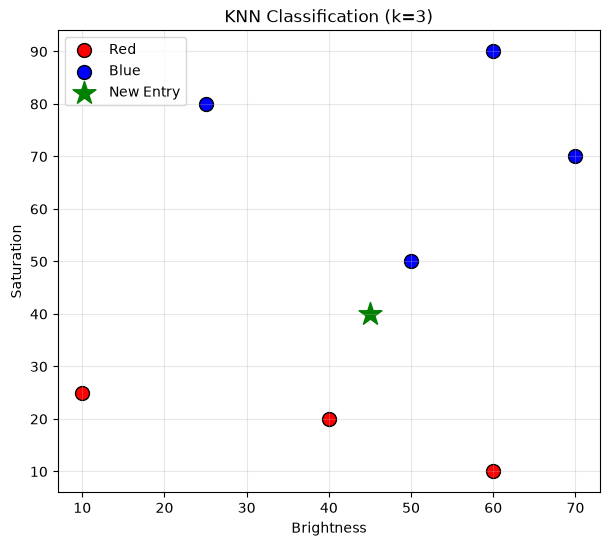

In [ ]:
plt.figure(figsize=(7, 6))
colors = {'Red': 'red', 'Blue': 'blue'}
for cls in df['Class'].unique():
    subset = df[df['Class'] == cls]
    plt.scatter(subset['Brightness'], subset['Saturation'], c=colors[cls], label=cls, edgecolors='k', s=100)
plt.scatter(new_entry[0], new_entry[1], c='green', marker='*', s=300, label='New Entry')
plt.xlabel('Brightness')
plt.ylabel('Saturation')
plt.title(f'KNN Classification (k={k})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()